# Analising NiSi XRD data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

### read file

In [3]:
# file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Ge\Stückchen\XRD\05112026_B2_exported.xy"
file_path = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Ge\Stückchen\XRD\05112026_B2_bg_subtracted.xy"

# data = pd.read_csv(file_path, delimiter="\t", skiprows=2, header=0, names=['Angle', 'Intensity'])
data = pd.read_csv(file_path, delimiter=" ", skiprows=1, header=None, names=['Angle', 'Intensity'])

filename = os.path.basename(file_path)
# name = filename.split("_", 7)[3:7]
# name = " ".join(name)
# print(name)

print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 2942 entries, 0 to 2941
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Angle      2942 non-null   float64
 1   Intensity  2942 non-null   float64
dtypes: float64(2)
memory usage: 46.1 KB
None


In [4]:
from processXRD import process_XRD_data

processed_data, peak_angles = process_XRD_data(data, roi=False, baseline_params={'lam': 5e6, 'p': 0.001, 'niter': 15}, peak_params={'prominence': 0.08, 'width': 10})
# processed_data, peak_angles = process_XRD_data(data, roi=False, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10}, peak_params={'prominence': 0.04, 'width': 5})
# processed_data, peak_angles = process_XRD_data(data, roi=True, roi_start=64.5, roi_end=66.5, baseline_params={'lam': 1e7, 'p': 0.0001, 'niter': 10}, peak_params={'prominence': 0.2, 'width': 20})

k:\tech_stud\Hager_Lutz\VS_Code\Master_data\XRD\processXRD.py:17: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


In [5]:
peak_angles = peak_angles.to_numpy()
peak_angles = np.append(peak_angles, 75.2432)

### plot basic spectra starting point

C:\Users\lhager\AppData\Local\Temp\ipykernel_18832\291052556.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.gca().set_ylim(bottom=0)
C:\Users\lhager\AppData\Local\Temp\ipykernel_18832\291052556.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


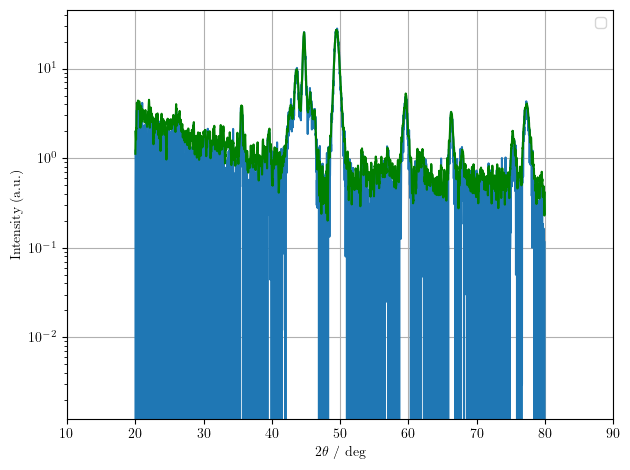

In [6]:
fig, ax = plt.subplots()
ax.plot(data['Angle'], data['Intensity'])
# ax.plot(processed_data['Angle'], processed_data['corrected'])
# ax.plot(processed_data['Angle'], processed_data['filtered'])
# ax.plot(processed_data['Angle'], processed_data['baseline'])
ax.semilogy(processed_data['Angle'], processed_data['filtered'], color='green')
ax.plot(processed_data['Angle'], processed_data['baseline'], color='red')
# ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(10, 90)
# plt.ylim(0, 30)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), name)}_processed.pdf', dpi=300)
plt.show()

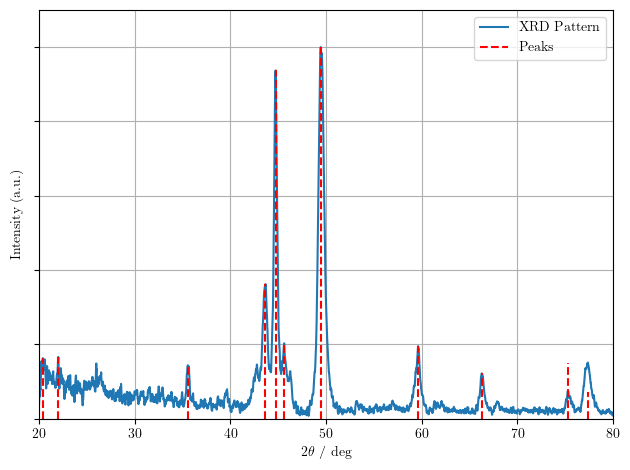

In [7]:
fig, ax = plt.subplots()

ax.plot(processed_data['Angle'], processed_data['intensity_norm'], label=f'XRD Pattern')
plt.vlines(peak_angles, ymin=0, ymax=processed_data[processed_data['Angle'].isin(peak_angles)]['intensity_norm'].values, color='red', linestyle='--', label='Peaks')
ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(20, 80)
plt.ylim(0, 1.1)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}_bessel.pdf', dpi=500)
plt.show()

# expermamenting with auto labeling

In [8]:
def auto_label_peaks(exp_peaks, ref_dict, tolerance=0.3):
    """Matches experimental peak positions to the best theoretical phase and HKL."""
    results = [] # Will store strings like "Ni (111)"

    for p_exp in exp_peaks:
        best_match = None
        highest_ref_int = -1
        
        for phase, data in ref_dict.items():
            ref_thetas = np.array(data['two_theta'])
            ref_intensities = np.array(data['intensity'])
            ref_hkls = data['hkl']
            
            diffs = np.abs(ref_thetas - p_exp)
            mask = diffs <= tolerance
            
            if np.any(mask):
                # Find the strongest theoretical peak within the tolerance
                idx = np.where(mask)[0][np.argmax(ref_intensities[mask])]
                current_max_int = ref_intensities[idx]
                
                if current_max_int > highest_ref_int:
                    highest_ref_int = current_max_int
                    hkl = ref_hkls[idx]
                    # Format as Phase (hkl)
                    best_match = f"{phase} ({hkl[0]}{hkl[1]}{hkl[2]})"
        
        results.append(best_match)
    return results

In [ ]:
reference_folder = r"K:\tech_stud\Hager_Lutz\Master\Experiments\Ni-Si\Stückchen\XRD\CIFs\Exports"

all_references = pd.DataFrame(columns=['two_theta', 'intensity', 'hkl'])
for file in os.listdir(reference_folder):
    filepath = os.path.join(reference_folder, file)
    cif_result = pd.read_csv(filepath, delimiter='\t', )
    print(cif_result)
print(all_references)

Empty DataFrame
Columns: [two_theta, intensity, hkl]
Index: []


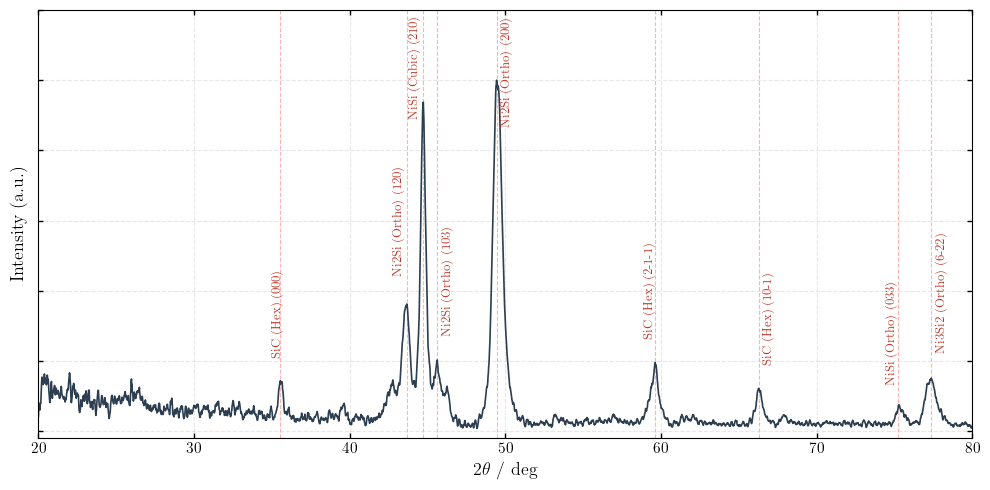

In [ ]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 5))

# Plot experimental data
ax.plot(processed_data['Angle'], processed_data['intensity_norm'], 
        color='#2c3e50', lw=1.2, zorder=2)

# Identify labels for peaks
labels = auto_label_peaks(peak_angles, all_references, tolerance=0.6)
# labels[0] = 'C (Hex) (002)'
# labels[0] = 'NiSi (Pnma) (211)'
# labels[1] = 'Ni_2Si (Pnma) (312)'


texts = []
for pos, label in zip(peak_angles, labels):
    if label:
        idx = np.abs(processed_data['Angle'] - pos).argmin()
        peak_height = processed_data['intensity_norm'].iloc[idx]
        
        ax.axvline(pos, color='red', linestyle='--', alpha=0.3, lw=0.8, zorder=1)
        
        t = ax.text(pos, peak_height + 0.02, label, 
                    rotation=90, fontsize=9, 
                    color='#c0392b', weight='bold',
                    va='bottom', ha='center')
        texts.append(t)

ax.set_ylim(-0.02, 1.2) 
adjust_text(texts, only_move={'points':'y', 'text':'xy'}, add_objects=[ax.lines[0]])


ax.set_yticklabels([])
# ax.set_xlim(10, 90)
ax.set_xlim(20, 80)
ax.set_ylim(-0.02, 1.2) # Increased upper limit to give labels room to breathe

ax.tick_params(axis='both', which='both', direction='in', 
                top=True, right=True, 
                width=1.0, labelsize=11)

ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

plt.tight_layout()
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), name)}_labeled.pdf', dpi=300)
# plt.savefig(f'{os.path.join(os.path.dirname(file_path), "B2_20nm_850")}_labeled.pdf', dpi=300)
plt.show()